# Notebook to visualize results on the test set

In [7]:
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt

sns.set_theme()

plt.rcParams["figure.figsize"] = [10, 5]

In [2]:
results_file = Path(
    "../scripts/endovis/endo17/results/Oct12_19.56.33_EndoVis17_Binary_CutOut_IoUs.json"
)
results_file.is_file()

True

In [3]:
# read the results file into a pandas dataframe
df = pd.read_json(results_file)
df.head()

,Oct12_19.56.33_EndoVis17_Binary_100.pth,Oct12_19.56.33_EndoVis17_Binary_200.pth,Oct12_19.56.33_EndoVis17_Binary_300.pth,Oct12_19.56.33_EndoVis17_Binary_400.pth,Oct12_19.56.33_EndoVis17_Binary_500.pth,Oct12_19.56.33_EndoVis17_Binary_600.pth,Oct12_19.56.33_EndoVis17_Binary_700.pth,Oct12_19.56.33_EndoVis17_Binary_800.pth,Oct12_19.56.33_EndoVis17_Binary_900.pth,Oct12_19.56.33_EndoVis17_Binary_1000.pth,...,Oct12_19.56.33_EndoVis17_Binary_2100.pth,Oct12_19.56.33_EndoVis17_Binary_2200.pth,Oct12_19.56.33_EndoVis17_Binary_2300.pth,Oct12_19.56.33_EndoVis17_Binary_2400.pth,Oct12_19.56.33_EndoVis17_Binary_2500.pth,Oct12_19.56.33_EndoVis17_Binary_2600.pth,Oct12_19.56.33_EndoVis17_Binary_2700.pth,Oct12_19.56.33_EndoVis17_Binary_2800.pth,Oct12_19.56.33_EndoVis17_Binary_2900.pth,Oct12_19.56.33_EndoVis17_Binary_3000.pth
instrument_dataset_03,0.824147,0.833981,0.842426,0.849217,0.831130,0.838159,0.856653,0.862106,0.841487,0.855370,...,0.880417,0.875950,0.882776,0.878156,0.878926,0.878086,0.879474,0.879000,0.879822,0.877289
instrument_dataset_05,0.845733,0.782441,0.831810,0.857570,0.845261,0.861507,0.857561,0.888883,0.869816,0.874163,...,0.898257,0.894181,0.899930,0.897373,0.897786,0.897846,0.898893,0.899180,0.899628,0.897374
instrument_dataset_04,0.937820,0.940887,0.940502,0.943793,0.942697,0.945206,0.945296,0.948517,0.948691,0.946660,...,0.952689,0.951255,0.951754,0.950710,0.951874,0.952096,0.951719,0.952204,0.952367,0.951890
instrument_dataset_07,0.930372,0.936923,0.938698,0.938980,0.937473,0.941052,0.937747,0.945492,0.945727,0.943930,...,0.950535,0.947068,0.948735,0.948264,0.949350,0.948922,0.949058,0.949368,0.949462,0.949041
instrument_dataset_06,0.870416,0.886739,0.887957,0.895771,0.883131,0.897494,0.901696,0.906783,0.900320,0.907075,...,0.914844,0.915578,0.917671,0.913272,0.914111,0.914129,0.914679,0.914429,0.914758,0.914798


In [4]:
# clean the column names to only contain the last part of the path
df.columns = df.columns.str.split("_").str[-1]
df.columns = df.columns.str.split(".").str[0]
df.head()

,100,200,300,400,500,600,700,800,900,1000,...,2100,2200,2300,2400,2500,2600,2700,2800,2900,3000
instrument_dataset_03,0.824147,0.833981,0.842426,0.849217,0.831130,0.838159,0.856653,0.862106,0.841487,0.855370,...,0.880417,0.875950,0.882776,0.878156,0.878926,0.878086,0.879474,0.879000,0.879822,0.877289
instrument_dataset_05,0.845733,0.782441,0.831810,0.857570,0.845261,0.861507,0.857561,0.888883,0.869816,0.874163,...,0.898257,0.894181,0.899930,0.897373,0.897786,0.897846,0.898893,0.899180,0.899628,0.897374
instrument_dataset_04,0.937820,0.940887,0.940502,0.943793,0.942697,0.945206,0.945296,0.948517,0.948691,0.946660,...,0.952689,0.951255,0.951754,0.950710,0.951874,0.952096,0.951719,0.952204,0.952367,0.951890
instrument_dataset_07,0.930372,0.936923,0.938698,0.938980,0.937473,0.941052,0.937747,0.945492,0.945727,0.943930,...,0.950535,0.947068,0.948735,0.948264,0.949350,0.948922,0.949058,0.949368,0.949462,0.949041
instrument_dataset_06,0.870416,0.886739,0.887957,0.895771,0.883131,0.897494,0.901696,0.906783,0.900320,0.907075,...,0.914844,0.915578,0.917671,0.913272,0.914111,0.914129,0.914679,0.914429,0.914758,0.914798


## Plot of average score per model

Text(0.5, 1.0, 'Test Performance of Binary Model with CutOut Augeumentation on Endo17 Test Set')

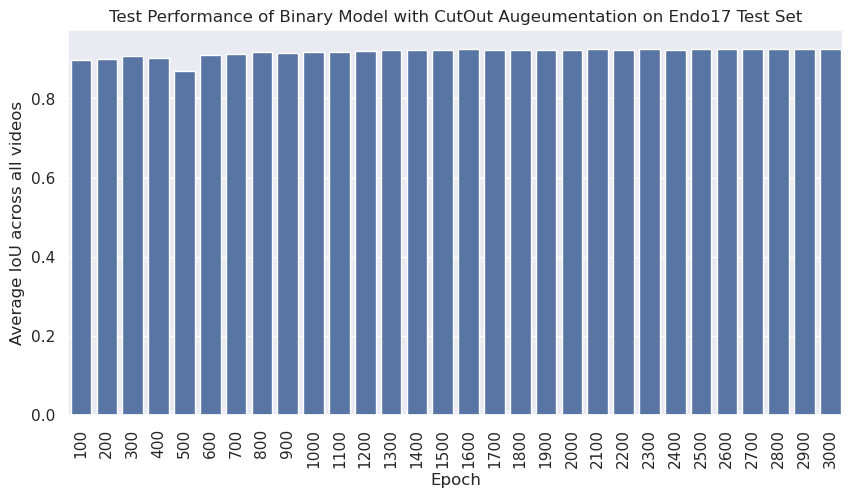

In [10]:
# bar plot of the mean IoU for each column
mean_iou = df.mean()
sns.barplot(x=mean_iou.index, y=mean_iou.values)
# rotate the xlabels to be vertical
plt.xticks(rotation=90)
plt.xlabel("Epoch")
plt.ylabel("Average IoU across all videos")
plt.title(
    "Test Performance of Binary Model with CutOut Augeumentation on Endo17 Test Set"
)

Text(0.5, 1.0, 'Test Performance of Binary Model with CutOut Augeumentation on Endo17 Patient 09')

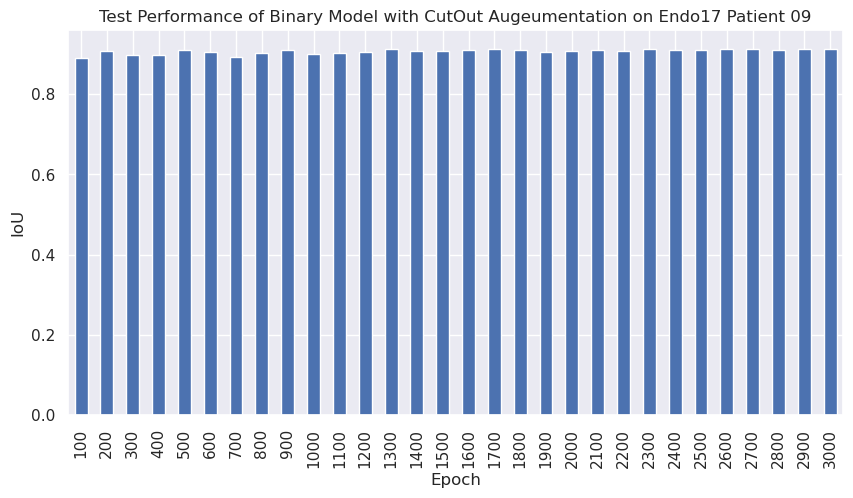

In [14]:
# plot the scores only for the last two rows of the dataframe for each column
df.iloc[-2].plot(kind="bar")
plt.xticks(rotation=90)
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(
    "Test Performance of Binary Model with CutOut Augeumentation on Endo17 Patient 09"
)

## Plot scores per video for a single model

Text(0.5, 1.0, 'Performance of model 3000 on test subset')

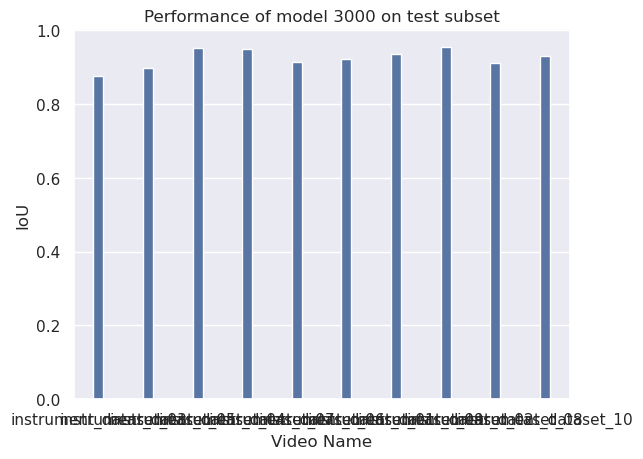

In [6]:
model_name = "3000"
model_scores = df[model_name]

sns.barplot(x=model_scores.index, y=model_scores.values, width=0.2)
plt.xlabel("Video Name")
plt.ylabel("IoU")
plt.title(f"Performance of model {model_name} on test subset")